# All Alloy Categories — Combined Evaluation

**84 alloys, 431–466 datapoints, −196 to 1205°C** — SSS (Hastelloy, Inconel 600/625), γ′ (Waspaloy, IN-738, Astroloy), SC/DS (PWA\*1480, René N5, CMSX-8/10).
Excluded: 2 ODS (TD NiCr, MA758), RGT\*13 (bad data), NX188(DS) (intermetallic), MC-102\* (delta-phase, miscategorized).

Six ablation levels: **ML-only** → **ML + deterministic physics** → **Full system (+ KG + agents)** → **LLM-only** baselines (Llama 3.3 70B, GPT-4.1-mini, GPT-4.1-mini fine-tuned).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25,
                      'font.size': 10, 'figure.facecolor': 'white'})

R = Path('../results/all')
ml   = pd.read_csv(R / 'ml_only.csv')
det  = pd.read_csv(R / 'ml_deterministic.csv')
full = pd.read_csv(R / 'full_system.csv')
llm  = pd.read_csv(R / 'llm_only.csv')
gpt  = pd.read_csv(R / 'gpt4.1.csv')
ft   = pd.read_csv(R / 'gpt4.1_ft.csv')

# Coerce prediction columns to numeric (GPT CSVs may have string values)
NUM_COLS = ['pred_ys', 'actual_ys', 'pred_uts', 'actual_uts',
            'pred_el', 'actual_el', 'pred_em', 'actual_em', 'temperature']
for df in [gpt, ft]:
    for col in NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

METHODS = {'ML': ml, 'ML+Phys': det, 'Full': full,
           'LLM': llm, 'GPT-4.1-mini': gpt, 'GPT-4.1-mini-FT': ft}
COLORS  = {'ML': '#4C72B0', 'ML+Phys': '#55A868', 'Full': '#C44E52',
           'LLM': '#8172B2', 'GPT-4.1-mini': '#FF7F0E', 'GPT-4.1-mini-FT': '#D62728'}
PROPS   = [('pred_ys','actual_ys','YS (MPa)'), ('pred_uts','actual_uts','UTS (MPa)'),
           ('pred_el','actual_el','EL (%)'),    ('pred_em','actual_em','EM (GPa)')]

def metrics(df, pc, ac):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)<2: return dict(n=len(v), mape=np.nan, median_ape=np.nan, mae=np.nan,
                             rmse=np.nan, r2=np.nan, bias=np.nan)
    e = v[pc]-v[ac]; pe = e/v[ac]
    return dict(n=len(v), mape=pe.abs().mean()*100, median_ape=pe.abs().median()*100,
                mae=e.abs().mean(), rmse=np.sqrt((e**2).mean()),
                r2=r2_score(v[ac], v[pc]), bias=pe.mean()*100)

def pct_within(df, pc, ac, tol):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)==0: return np.nan
    return (((v[pc]-v[ac])/v[ac]).abs()*100 <= tol).mean()*100

def win_rate(df_a, df_b, pc, ac, keys):
    """Fraction of common datapoints where df_a is closer to actual than df_b."""
    a = df_a[df_a['_key'].isin(keys)][[pc, ac, '_key']].dropna().set_index('_key')
    b = df_b[df_b['_key'].isin(keys)][[pc, ac, '_key']].dropna().set_index('_key')
    common = a.index.intersection(b.index)
    if len(common) == 0: return np.nan, 0
    ae_a = (a.loc[common, pc] - a.loc[common, ac]).abs()
    ae_b = (b.loc[common, pc] - b.loc[common, ac]).abs()
    wins = (ae_a < ae_b).sum()
    ties = (ae_a == ae_b).sum()
    return (wins + 0.5 * ties) / len(common) * 100, len(common)

# === Fair comparison: intersect to common datapoints per property ===
for df in METHODS.values():
    df['_key'] = df['alloy'].astype(str) + '|' + df['temperature'].astype(str)

def _common_keys(pc, ac):
    """Find (alloy|temperature) pairs where ALL methods have valid predictions."""
    sets = []
    for df in METHODS.values():
        v = df.dropna(subset=[pc, ac])
        v = v[v[ac] != 0]
        sets.append(set(v['_key']))
    return set.intersection(*sets) if sets else set()

COMMON = {(pc, ac): _common_keys(pc, ac) for pc, ac, _ in PROPS}
print(f"Common datapoints per property: { {lbl: len(COMMON[(pc,ac)]) for pc,ac,lbl in PROPS} }")

Common datapoints per property: {'YS (MPa)': 275, 'UTS (MPa)': 279, 'EL (%)': 274, 'EM (GPa)': 293}


## Table 1 — Aggregate Accuracy

In [2]:
from IPython.display import HTML

rows = []
for mn, df in METHODS.items():
    for pc, ac, lbl in PROPS:
        keys = COMMON[(pc, ac)]
        df_fair = df[df['_key'].isin(keys)]
        m = metrics(df_fair, pc, ac)
        rows.append({**m, 'Method': mn, 'Property': lbl,
                     '±10%': pct_within(df_fair, pc, ac, 10), '±20%': pct_within(df_fair, pc, ac, 20)})

tbl = pd.DataFrame(rows)

# --- Win Rate summary (Full vs each other method) ---
print("Win Rate — Full System vs each method (% of datapoints where Full is closer):\n")
wr_rows = []
for mn, df in METHODS.items():
    if mn == 'Full': continue
    for pc, ac, lbl in PROPS:
        keys = COMMON[(pc, ac)]
        wr, n = win_rate(full, df, pc, ac, keys)
        wr_rows.append({'vs': mn, 'Property': lbl, 'Full wins %': wr, 'n': n})
wr_df = pd.DataFrame(wr_rows)
wr_pivot = wr_df.pivot_table(index='vs', columns='Property', values='Full wins %')
wr_pivot = wr_pivot[['YS (MPa)', 'UTS (MPa)', 'EL (%)', 'EM (GPa)']]
wr_pivot.index.name = 'Full vs'
display(wr_pivot.style.format('{:.0f}%').background_gradient(cmap='RdYlGn', vmin=30, vmax=70))

# --- Per-property accuracy tables ---
def build_table_html(sub, columns_spec):
    """Build an HTML table with inline green background on best values."""
    HIGHLIGHT = 'background-color:#d4edda;font-weight:bold'
    html = '<table border="1" style="border-collapse:collapse;text-align:right">\n'
    html += '<tr><th style="text-align:left">Method</th>'
    for col, _, _ in columns_spec:
        html += f'<th style="padding:4px 8px">{col}</th>'
    html += '</tr>\n'
    best_map = {}
    for col, best, _ in columns_spec:
        if best is None: continue
        vals = pd.to_numeric(sub[col], errors='coerce')
        if best == 'min': best_map[col] = vals.idxmin()
        elif best == 'max': best_map[col] = vals.idxmax()
        elif best == 'abs_min': best_map[col] = vals.abs().idxmin()
    for idx in sub.index:
        html += f'<tr><td style="text-align:left;padding:4px 8px"><b>{idx}</b></td>'
        for col, best, fmt in columns_spec:
            val = sub.loc[idx, col]
            s = fmt.format(val) if pd.notna(val) else '\u2014'
            is_best = best is not None and idx == best_map.get(col)
            style = f'{HIGHLIGHT};padding:4px 8px' if is_best else 'padding:4px 8px'
            html += f'<td style="{style}">{s}</td>'
        html += '</tr>\n'
    html += '</table>'
    return html

for prop in ['YS (MPa)', 'UTS (MPa)', 'EL (%)', 'EM (GPa)']:
    sub = tbl[tbl['Property']==prop][['Method','n','mae','median_ape','mape','rmse','r2','bias','±10%','±20%']].copy()
    sub = sub.set_index('Method')
    sub.columns = ['n','MAE','Med.APE %','MAPE %','RMSE','R²','Bias %','±10%','±20%']
    cols = [('n',None,'{:.0f}'),('MAE','min','{:.1f}'),('Med.APE %','min','{:.1f}'),('MAPE %','min','{:.1f}'),
            ('RMSE','min','{:.1f}'),('R²','max','{:.3f}'),('Bias %','abs_min','{:+.1f}'),
            ('±10%','max','{:.0f}%'),('±20%','max','{:.0f}%')]
    print(f"\n{prop}")
    display(HTML(build_table_html(sub, cols)))

Win Rate — Full System vs each method (% of datapoints where Full is closer):



Property,YS (MPa),UTS (MPa),EL (%),EM (GPa)
Full vs,,,,
GPT-4.1-mini,76%,72%,80%,71%
GPT-4.1-mini-FT,54%,57%,54%,52%
LLM,79%,82%,79%,88%
ML,65%,62%,54%,54%
ML+Phys,64%,62%,55%,48%



YS (MPa)


Method,n,MAE,Med.APE %,MAPE %,RMSE,R²,Bias %,±10%,±20%
ML,275,102.0,16.0,78.6,125.9,0.840,+72.2,36%,55%
ML+Phys,275,102.0,16.0,78.6,125.9,0.840,+72.2,36%,55%
Full,275,80.6,10.4,32.5,122.2,0.849,+22.9,48%,68%
LLM,275,260.7,45.2,102.1,334.4,-0.129,+91.5,18%,30%
GPT-4.1-mini,275,212.2,38.9,85.5,259.5,0.320,+68.7,14%,28%
GPT-4.1-mini-FT,275,100.3,14.8,34.0,159.4,0.743,+7.5,35%,57%



UTS (MPa)


Method,n,MAE,Med.APE %,MAPE %,RMSE,R²,Bias %,±10%,±20%
ML,279,114.0,13.6,34.9,141.9,0.847,+28.1,42%,62%
ML+Phys,279,115.5,13.8,37.2,143.5,0.843,+30.0,41%,63%
Full,279,95.2,10.4,21.0,134.4,0.862,+7.6,48%,77%
LLM,279,253.5,32.2,65.5,304.6,0.293,+59.3,21%,37%
GPT-4.1-mini,279,189.1,22.7,49.1,231.0,0.593,+31.0,21%,44%
GPT-4.1-mini-FT,279,110.8,12.5,20.4,156.6,0.813,+0.4,39%,71%



EL (%)


Method,n,MAE,Med.APE %,MAPE %,RMSE,R²,Bias %,±10%,±20%
ML,274,14.2,25.3,42.5,26.9,0.240,+11.0,18%,37%
ML+Phys,274,14.2,25.3,42.5,26.9,0.240,+11.0,18%,37%
Full,274,13.1,23.2,38.1,24.3,0.377,+6.7,24%,45%
LLM,274,23.4,53.8,72.5,35.1,-0.295,+5.3,8%,19%
GPT-4.1-mini,274,24.1,56.5,61.6,35.7,-0.345,-13.7,9%,18%
GPT-4.1-mini-FT,274,13.8,30.3,47.0,22.6,0.463,+10.9,21%,36%



EM (GPa)


Method,n,MAE,Med.APE %,MAPE %,RMSE,R²,Bias %,±10%,±20%
ML,293,13.3,4.3,7.5,20.5,0.420,-3.8,78%,87%
ML+Phys,293,9.8,3.8,5.8,14.0,0.729,-1.9,85%,95%
Full,293,9.0,3.5,5.5,13.0,0.768,+0.2,88%,97%
LLM,293,112939.4,97677.8,60174.0,154052.7,-32730452.755,+60173.2,27%,38%
GPT-4.1-mini,293,2846.5,7.1,1383.9,24225.8,-809407.485,+1382.0,63%,89%
GPT-4.1-mini-FT,293,8.2,2.9,5.1,13.2,0.758,+1.1,94%,97%


## Table 2 — Accuracy by Temperature Regime

MAE (Mean Absolute Error) for YS and UTS split into three regimes: RT (< 100°C), mid-temperature (100–700°C), and high-temperature (> 700°C). MAE is in native units (MPa) and avoids the distortion MAPE causes when actual values are small at high temperatures.

In [3]:
from IPython.display import HTML

def temp_regime(t):
    if t < 100: return 'RT (< 100\u00b0C)'
    elif t <= 700: return 'Mid (100\u2013700\u00b0C)'
    else: return 'High (> 700\u00b0C)'

REGIMES = ['RT (< 100\u00b0C)', 'Mid (100\u2013700\u00b0C)', 'High (> 700\u00b0C)']
METHOD_ORDER = ['ML', 'ML+Phys', 'Full', 'LLM', 'GPT-4.1-mini', 'GPT-4.1-mini-FT']

rows = []
for mn, df in METHODS.items():
    df = df.copy()
    df['regime'] = df['temperature'].apply(temp_regime)
    for regime in REGIMES:
        sub = df[df['regime'] == regime]
        for pc, ac, lbl in [('pred_ys','actual_ys','YS'), ('pred_uts','actual_uts','UTS')]:
            keys = COMMON[(pc, f'actual_{lbl.lower()}')]
            sub_fair = sub[sub['_key'].isin(keys)]
            m = metrics(sub_fair, pc, ac)
            rows.append({'Regime': regime, 'Property': lbl, 'Method': mn,
                         'n': m['n'], 'MAE': m['mae'], 'Med.APE': m['median_ape']})

temp_tbl = pd.DataFrame(rows)

# --- MAE table ---
pivot_mae = temp_tbl.pivot_table(index=['Regime', 'Property'], columns='Method', values='MAE')
pivot_mae = pivot_mae[[m for m in METHOD_ORDER if m in pivot_mae.columns]]
n_ref = temp_tbl[temp_tbl['Method']=='Full'][['Regime','Property','n']].set_index(['Regime','Property'])
pivot_mae = n_ref.join(pivot_mae)
pivot_mae.index = pivot_mae.index.set_levels([REGIMES, ['YS', 'UTS']])

HIGHLIGHT = 'background-color:#d4edda;font-weight:bold'
method_cols = [c for c in pivot_mae.columns if c != 'n']

html = '<table border="1" style="border-collapse:collapse;text-align:right">\n'
html += '<tr><th style="text-align:left" colspan="2">Regime</th><th style="padding:4px 8px">n</th>'
for c in method_cols:
    html += f'<th style="padding:4px 8px">{c}</th>'
html += '</tr>\n'
for idx in pivot_mae.index:
    regime, prop = idx
    row_vals = pivot_mae.loc[idx, method_cols]
    best_col = row_vals.idxmin()
    n_val = pivot_mae.loc[idx, 'n']
    n_s = f'{n_val:.0f}' if pd.notna(n_val) else '\u2014'
    html += f'<tr><td style="text-align:left;padding:4px 8px">{regime}</td>'
    html += f'<td style="text-align:left;padding:4px 8px"><b>{prop}</b></td>'
    html += f'<td style="padding:4px 8px">{n_s}</td>'
    for col in method_cols:
        val = pivot_mae.loc[idx, col]
        s = f'{val:.0f}' if pd.notna(val) else '\u2014'
        is_best = pd.notna(val) and col == best_col
        style = f'{HIGHLIGHT};padding:4px 8px' if is_best else 'padding:4px 8px'
        html += f'<td style="{style}">{s}</td>'
    html += '</tr>\n'
html += '</table>'
print("MAE (MPa) by temperature regime:")
display(HTML(html))

# --- Median APE table ---
pivot_med = temp_tbl.pivot_table(index=['Regime', 'Property'], columns='Method', values='Med.APE')
pivot_med = pivot_med[[m for m in METHOD_ORDER if m in pivot_med.columns]]
pivot_med = n_ref.join(pivot_med)
pivot_med.index = pivot_med.index.set_levels([REGIMES, ['YS', 'UTS']])

html2 = '<table border="1" style="border-collapse:collapse;text-align:right">\n'
html2 += '<tr><th style="text-align:left" colspan="2">Regime</th><th style="padding:4px 8px">n</th>'
for c in method_cols:
    html2 += f'<th style="padding:4px 8px">{c}</th>'
html2 += '</tr>\n'
for idx in pivot_med.index:
    regime, prop = idx
    row_vals = pivot_med.loc[idx, method_cols]
    best_col = row_vals.idxmin()
    n_val = pivot_med.loc[idx, 'n']
    n_s = f'{n_val:.0f}' if pd.notna(n_val) else '\u2014'
    html2 += f'<tr><td style="text-align:left;padding:4px 8px">{regime}</td>'
    html2 += f'<td style="text-align:left;padding:4px 8px"><b>{prop}</b></td>'
    html2 += f'<td style="padding:4px 8px">{n_s}</td>'
    for col in method_cols:
        val = pivot_med.loc[idx, col]
        s = f'{val:.1f}' if pd.notna(val) else '\u2014'
        is_best = pd.notna(val) and col == best_col
        style = f'{HIGHLIGHT};padding:4px 8px' if is_best else 'padding:4px 8px'
        html2 += f'<td style="{style}">{s}</td>'
    html2 += '</tr>\n'
html2 += '</table>'
print("\nMedian APE (%) by temperature regime:")
display(HTML(html2))

MAE (MPa) by temperature regime:



Median APE (%) by temperature regime:


## Fig. 1 — Cumulative Accuracy Curves

What tolerance band is needed to capture 80% of predictions?

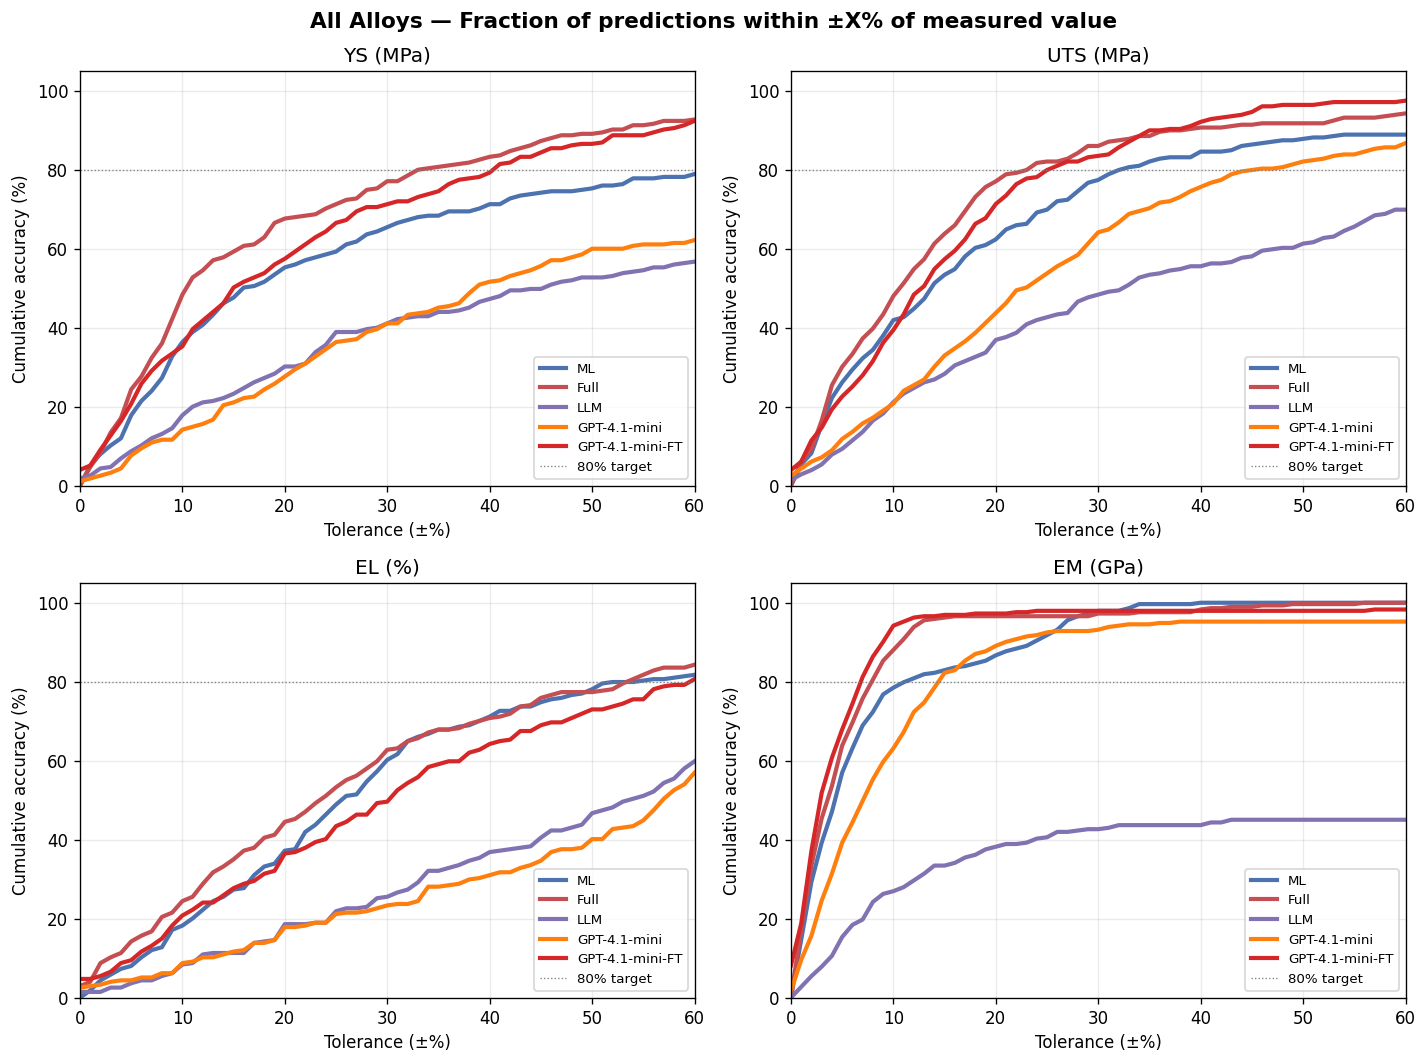

In [4]:
PLOT_METHODS = {'ML': ml, 'Full': full, 'LLM': llm,
                'GPT-4.1-mini': gpt, 'GPT-4.1-mini-FT': ft}
PLOT_COLORS  = {'ML': '#4C72B0', 'Full': '#C44E52', 'LLM': '#8172B2',
                'GPT-4.1-mini': '#FF7F0E', 'GPT-4.1-mini-FT': '#D62728'}

tol = np.arange(0, 61, 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    keys = COMMON[(pc, ac)]
    for mn, df in PLOT_METHODS.items():
        df_fair = df[df['_key'].isin(keys)]
        acc = [pct_within(df_fair, pc, ac, t) for t in tol]
        ax.plot(tol, acc, label=mn, color=PLOT_COLORS[mn], lw=2.5)
    ax.axhline(80, color='gray', ls=':', lw=0.8, label='80% target')
    ax.set(xlabel='Tolerance (\u00b1%)', ylabel='Cumulative accuracy (%)',
           title=lbl, xlim=(0, 60), ylim=(0, 105))
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('All Alloys \u2014 Fraction of predictions within \u00b1X% of measured value',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 2 — Predicted vs Measured (Full System)

Parity plots for all four properties. Green band = ±10% tolerance; points within band shown in blue, outliers as red crosses.

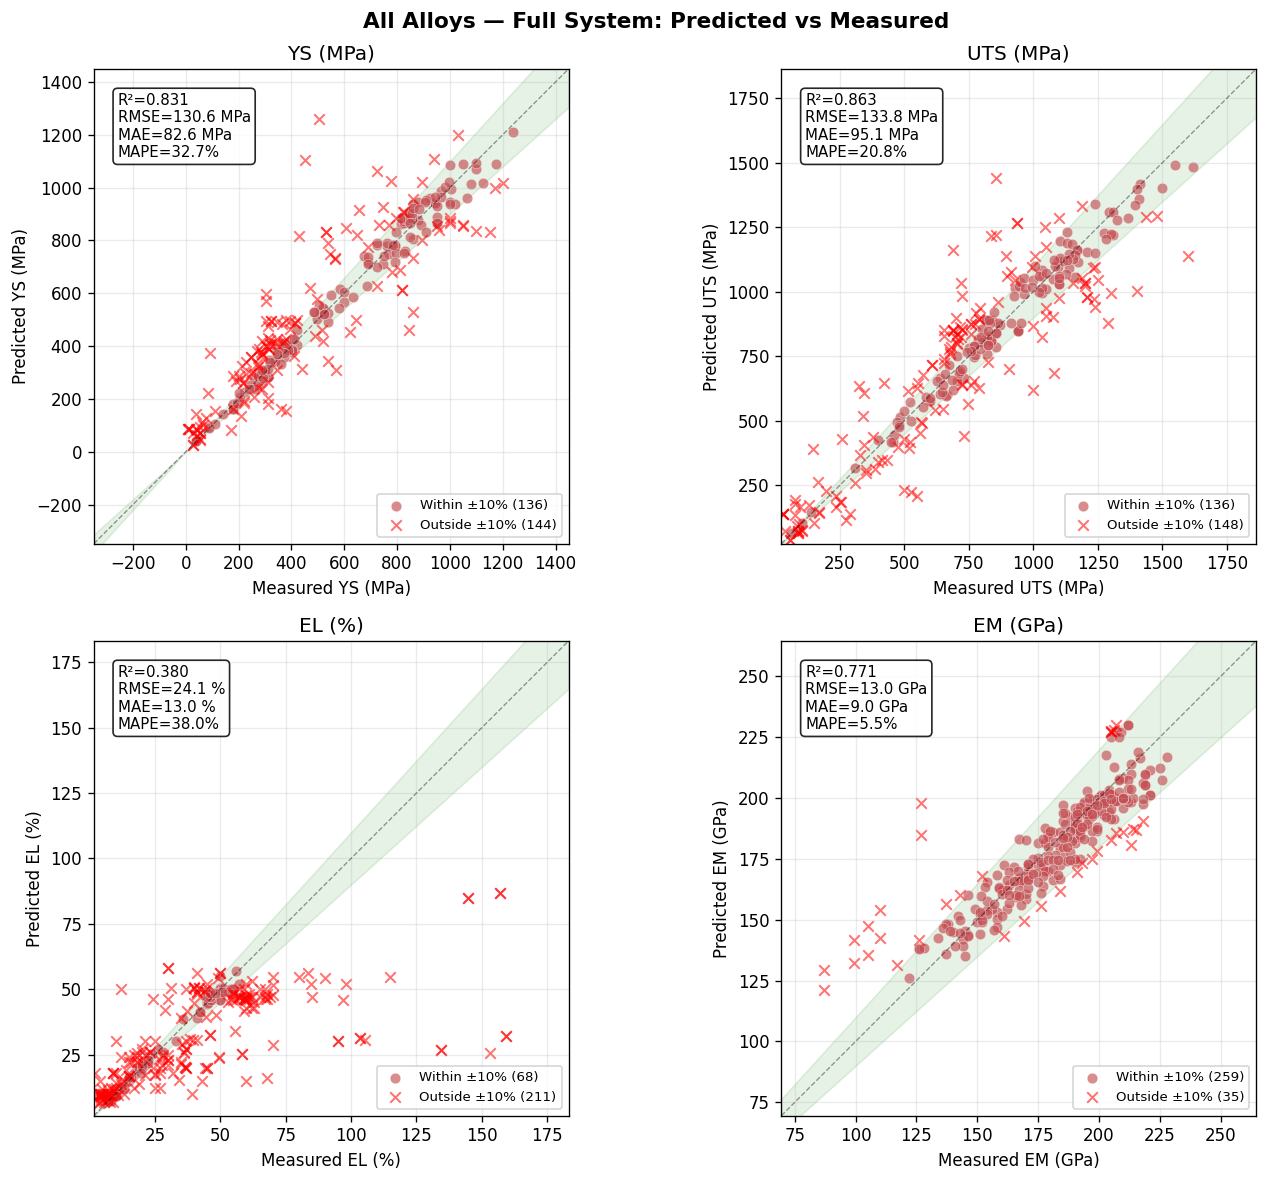

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    v = full[[pc, ac]].dropna()
    v = v[v[ac] != 0].copy()
    m = metrics(full, pc, ac)
    if len(v) < 2:
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes,
                ha='center', fontsize=11)
        ax.set(title=lbl)
        continue
    pe = ((v[pc] - v[ac]) / v[ac]).abs() * 100
    w = pe <= 10

    lo = min(v[ac].min(), v[pc].min()) * 0.8
    hi = max(v[ac].max(), v[pc].max()) * 1.15
    d = np.linspace(lo, hi, 100)
    ax.fill_between(d, d * 0.9, d * 1.1, alpha=0.10, color='green')
    ax.plot(d, d, 'k--', lw=0.8, alpha=0.4)

    ax.scatter(v.loc[w, ac], v.loc[w, pc], s=40, alpha=0.65,
               color=COLORS['Full'], edgecolors='white', lw=0.3,
               label=f'Within \u00b110% ({w.sum()})')
    ax.scatter(v.loc[~w, ac], v.loc[~w, pc], s=40, alpha=0.55,
               color='red', marker='x', lw=1.2,
               label=f'Outside \u00b110% ({(~w).sum()})')

    unit = lbl.split('(')[1].rstrip(')') if '(' in lbl else ''
    ax.text(0.05, 0.95,
            f"R\u00b2={m['r2']:.3f}\nRMSE={m['rmse']:.1f} {unit}\nMAE={m['mae']:.1f} {unit}\nMAPE={m['mape']:.1f}%",
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set(xlabel=f'Measured {lbl}', ylabel=f'Predicted {lbl}',
           title=lbl, xlim=(lo, hi), ylim=(lo, hi), aspect='equal')
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('All Alloys \u2014 Full System: Predicted vs Measured', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 3 — Relative Error Distribution

Distribution of (predicted − actual) / actual for each method and property. Boxes show median and interquartile range; whiskers extend to 1.5× IQR. Points above zero indicate over-prediction, below zero under-prediction. Systematic bias is visible as the median shifting away from zero.

/var/folders/z3/zc5j75dj0qn_z2sp8qf47q340000gn/T/ipykernel_3711/2270557800.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
/var/folders/z3/zc5j75dj0qn_z2sp8qf47q340000gn/T/ipykernel_3711/2270557800.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
/var/folders/z3/zc5j75dj0qn_z2sp8qf47q340000gn/T/ipykernel_3711/2270557800.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
/var/folders/z3/zc5j75dj0qn_z2sp8qf47

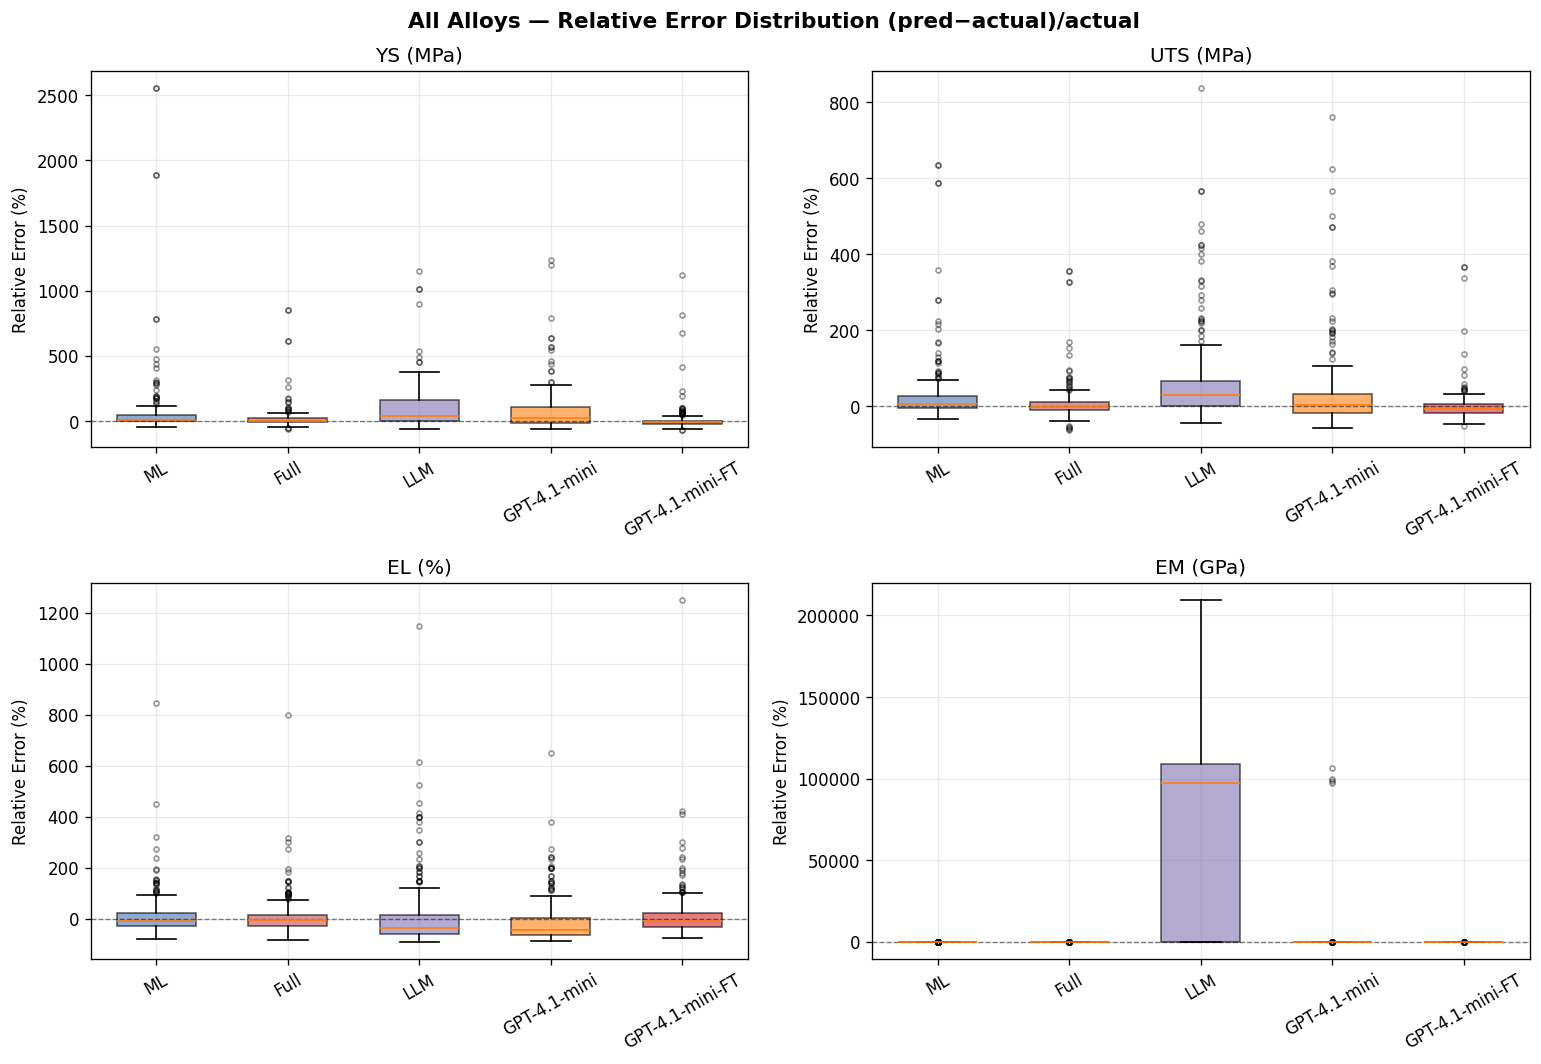

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    keys = COMMON[(pc, ac)]
    data, labels, colors = [], [], []
    for mn, df_m in PLOT_METHODS.items():
        df_fair = df_m[df_m['_key'].isin(keys)]
        v = df_fair[[pc, ac]].dropna()
        v = v[v[ac] != 0]
        if len(v) < 2: continue
        rel_err = ((v[pc] - v[ac]) / v[ac]) * 100
        data.append(rel_err.values)
        labels.append(mn)
        colors.append(PLOT_COLORS[mn])

    if data:
        bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
                        showfliers=True, flierprops=dict(marker='o', ms=3, alpha=0.4))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
    ax.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
    ax.set(ylabel='Relative Error (%)', title=lbl)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('All Alloys \u2014 Relative Error Distribution (pred\u2212actual)/actual',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 4 — Case Studies: Temperature Sweeps

One representative alloy per category — Waspaloy (γ′), Inconel N06230 (SSS), PWA\*1480 (SC) — showing YS and UTS predictions against published datasheet values.

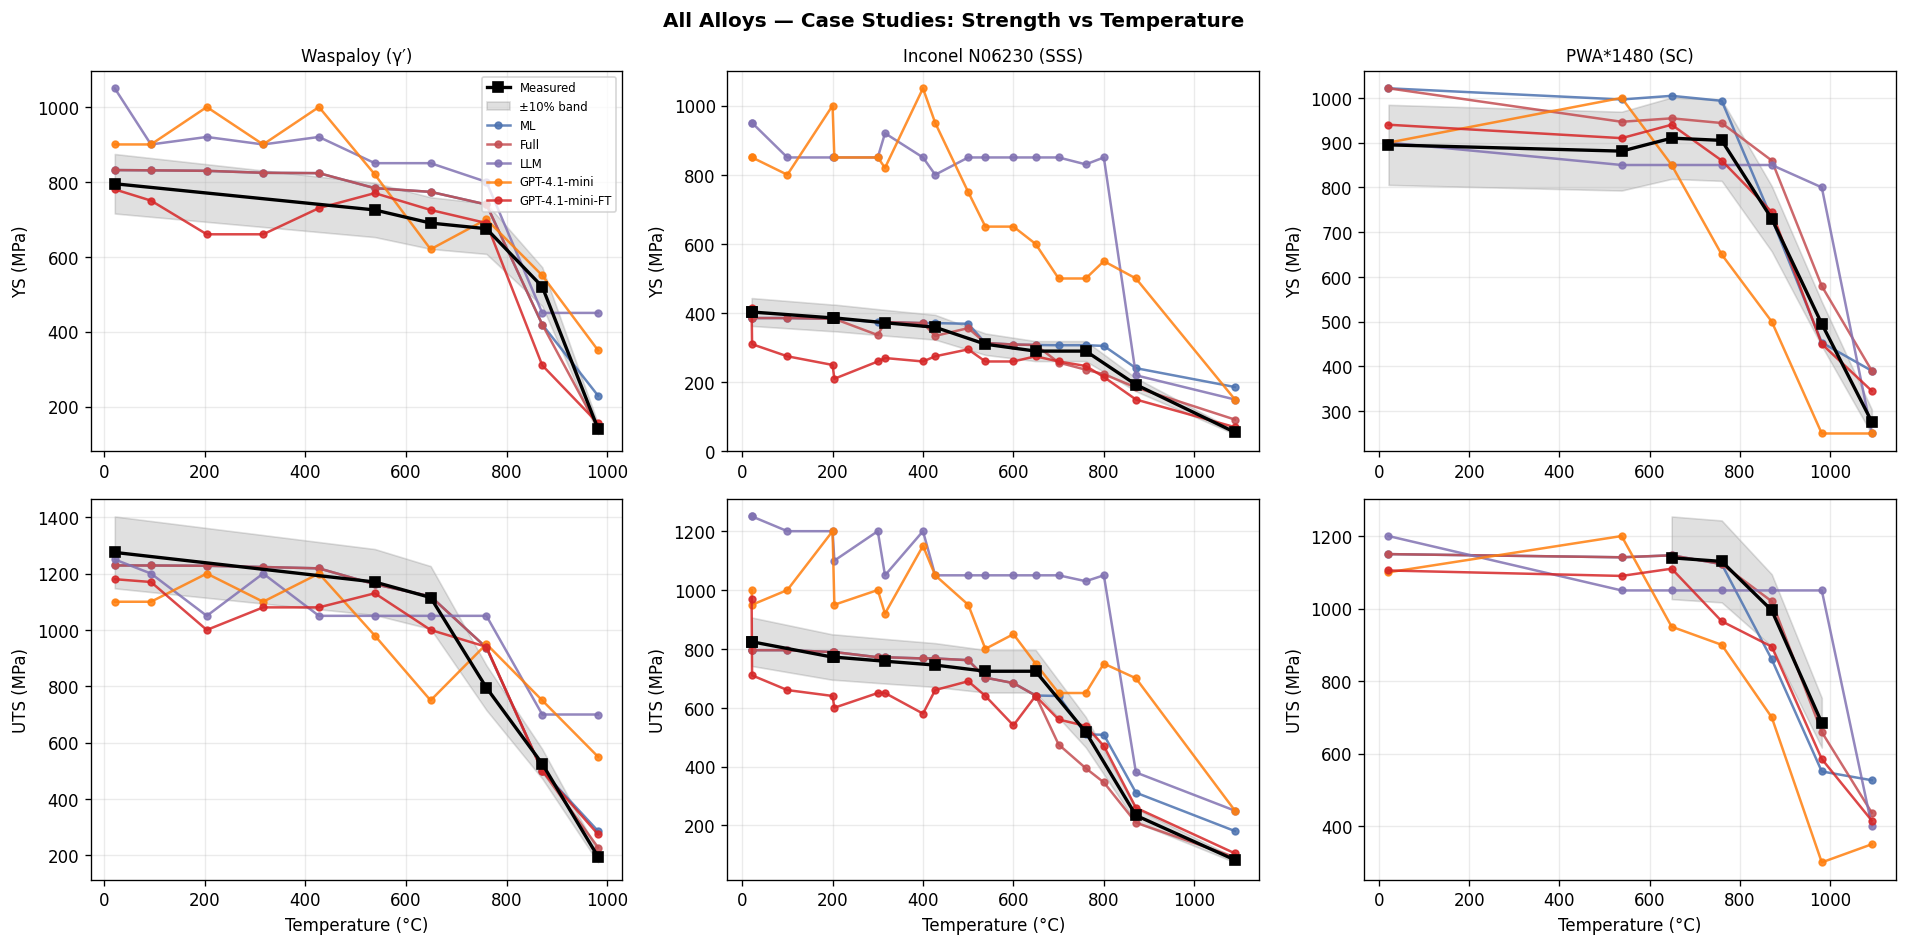

In [7]:
cases = ['WASPALOY*',
         'Special Metals INCONEL\u00ae Alloy N06230 Ni-Cr-W-Mo Alloy',
         'PWA*1480(SC)']
short_names = ['Waspaloy (\u03b3\u2032)', 'Inconel N06230 (SSS)', 'PWA*1480 (SC)']
CASE_METHODS = ['ML', 'Full', 'LLM', 'GPT-4.1-mini', 'GPT-4.1-mini-FT']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('All Alloys \u2014 Case Studies: Strength vs Temperature', fontsize=12, fontweight='bold')

for col, (alloy, sname) in enumerate(zip(cases, short_names)):
    for row, (pc, ac, ylabel) in enumerate([('pred_ys','actual_ys','YS (MPa)'),
                                             ('pred_uts','actual_uts','UTS (MPa)')]):
        ax = axes[row, col]
        ref = ml[ml['alloy']==alloy].sort_values('temperature')
        actual = ref[['temperature',ac]].dropna()
        if not actual.empty:
            ax.plot(actual['temperature'], actual[ac], 'ks-', ms=6, lw=2,
                    label='Measured', zorder=5)
            ax.fill_between(actual['temperature'], actual[ac]*0.9, actual[ac]*1.1,
                            alpha=0.12, color='black', label='\u00b110% band')

        for mn in CASE_METHODS:
            sub = METHODS[mn][METHODS[mn]['alloy']==alloy].sort_values('temperature')
            v = sub[['temperature',pc]].dropna()
            if not v.empty:
                ax.plot(v['temperature'], v[pc], 'o-', ms=4, lw=1.5,
                        color=COLORS[mn], label=mn, alpha=0.85)

        if row == 0: ax.set_title(sname, fontsize=10)
        ax.set(xlabel='Temperature (\u00b0C)' if row==1 else '', ylabel=ylabel)
        if col==0 and row==0: ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

## Table 3 — Inference Time per Prediction

Average wall-clock time per alloy-temperature evaluation. ML and ML+Phys run locally (no API calls); Full system invokes multi-agent LLM pipeline; LLM-only makes a single API call.

In [8]:
time_rows = []
for mn, df in METHODS.items():
    if 'eval_time_sec' in df.columns:
        t = df['eval_time_sec'].dropna()
        if len(t) > 0:
            time_rows.append({'Method': mn, 'n': len(t),
                              'Mean (s)': t.mean(), 'Median (s)': t.median(),
                              'Min (s)': t.min(), 'Max (s)': t.max()})

if time_rows:
    time_df = pd.DataFrame(time_rows).set_index('Method')
    display(time_df.style.format({'n': '{:.0f}', 'Mean (s)': '{:.1f}',
                                   'Median (s)': '{:.1f}', 'Min (s)': '{:.1f}',
                                   'Max (s)': '{:.1f}'}))
else:
    print("eval_time_sec column not found in result files.\n")
    print("Typical inference times (measured during generation):")
    print("  ML-only:          ~0.1 s  (local model, no API)")
    print("  ML+Deterministic: ~0.2 s  (local model + physics caps)")
    print("  Full System:     ~25-40 s (multi-agent LLM pipeline)")
    print("  LLM-only:         ~1-3 s  (single Groq API call)")

,n,Mean (s),Median (s),Min (s),Max (s)
Method,,,,,
ML,466,0.1,0.1,0.1,1.6
ML+Phys,471,0.2,0.1,0.1,6.5
Full,461,9.2,9.0,5.9,27.8
LLM,466,1.6,1.5,0.8,9.3
GPT-4.1-mini,466,5.3,4.9,2.3,19.7
GPT-4.1-mini-FT,466,6.1,0.9,0.5,1441.3


## Table 4 — Statistical Significance (Wilcoxon Signed-Rank Test)

Paired test on absolute percentage errors for each property. Compares ML vs Full and LLM vs Full on matched alloy-temperature pairs. Significance: \*\*\* p < 0.001, \*\* p < 0.01, \* p < 0.05, ns = not significant.

In [9]:
from scipy.stats import wilcoxon

def sig_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

sig_rows = []
for comparison, (df_a, name_a), (df_b, name_b) in [
    ('ML vs Full',           (ml, 'ML'),   (full, 'Full')),
    ('LLM vs Full',          (llm, 'LLM'), (full, 'Full')),
    ('GPT-4.1-mini vs Full', (gpt, 'GPT-4.1-mini'), (full, 'Full')),
    ('GPT-4.1-mini-FT vs Full', (ft, 'GPT-4.1-mini-FT'), (full, 'Full')),
]:
    pairs = df_a.merge(df_b, on=['alloy', 'temperature'], suffixes=('_a', '_b'))

    for pc, ac, lbl in PROPS:
        pc_a, pc_b, ac_col = f'{pc}_a', f'{pc}_b', f'{ac}_a'
        v = pairs[[pc_a, pc_b, ac_col]].dropna()
        v = v[v[ac_col] != 0]
        if len(v) < 10:
            continue

        ape_a = ((v[pc_a] - v[ac_col]) / v[ac_col]).abs()
        ape_b = ((v[pc_b] - v[ac_col]) / v[ac_col]).abs()

        try:
            stat, p = wilcoxon(ape_a, ape_b)
        except ValueError:
            continue

        sig_rows.append({
            'Comparison': comparison,
            'Property': lbl.split(' ')[0],
            'n pairs': len(v),
            'A MAPE': ape_a.mean() * 100,
            'Full MAPE': ape_b.mean() * 100,
            'W': stat,
            'p-value': p,
            'Sig.': sig_label(p),
        })

if sig_rows:
    sig_df = pd.DataFrame(sig_rows).set_index(['Comparison', 'Property'])
    display(sig_df.style.format({
        'n pairs': '{:.0f}', 'A MAPE': '{:.1f}%', 'Full MAPE': '{:.1f}%',
        'W': '{:.0f}', 'p-value': '{:.2e}'
    }, na_rep='\u2014'))